In [11]:
import numpy as np
import matplotlib.pyplot as plt

from helpers.geometry_map import make_geometry_map, build_dist_tree_from_map
from helpers.data_transforms import load_in_data

from tqdm import tqdm
from helpers.material_map import apply_material_map_hybrid


In [2]:
geo_map_path = "/pscratch/sd/r/rmastand/muon_collider/geometry_map.txt"

# make_geometry_map(
#     df,
#     collections,
#     geo_map_path,
#     num_events_per_col=1_000_000,
    
# )

In [3]:
tree_map, cellid_layer_map = build_dist_tree_from_map(geo_map_path)

Loaded geometry map with 6000000 hits across 6 collections


In [4]:


collections = [
    "InnerTrackerBarrelCollection",
   "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
    "OuterTrackerEndcapCollection",  
    "VertexBarrelCollection",   
    "VertexEndcapCollection",
]


feature_order_endcap = [0, 4, 1, 2, 3,  5, 6]
feature_indices_dict_endcap = {
    "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6
}

feature_order_barrel =[0, 4, 2, 3, 1,  5, 6]
feature_indices_dict_barrel = {
    "r":4,
    "phi": 2,
    "z":3,
    "side":5,
    "layer":6
}

feature_order_dict = {
     "InnerTrackerBarrelCollection":feature_order_barrel,
    "InnerTrackerEndcapCollection":feature_order_endcap,
    "OuterTrackerBarrelCollection":feature_order_barrel,
    "OuterTrackerEndcapCollection":feature_order_endcap,  
    "VertexBarrelCollection":feature_order_barrel,
    "VertexEndcapCollection":feature_order_endcap,

}


feature_indices_dict = {
     "InnerTrackerBarrelCollection":feature_indices_dict_barrel,
    "InnerTrackerEndcapCollection":feature_indices_dict_endcap,
    "OuterTrackerBarrelCollection":feature_indices_dict_barrel,
    "OuterTrackerEndcapCollection":feature_indices_dict_endcap,  
    "VertexBarrelCollection":feature_indices_dict_barrel,
    "VertexEndcapCollection":feature_indices_dict_endcap,

}



ZUKO_ID = "NCSF"
NAME = "XXL_2048_cond3"
NUM_COND_INPUTS = 3



FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = []

In [5]:
# load in samples

all_data_dir, all_samples_dir = {}, {}


for col_name in collections:

    small_id = ''.join([c for c in col_name if c.isupper()])
    X, feature_labels = load_in_data([col_name], FEATURES, working_dir, 1, NUM_COND_INPUTS, feature_order_dict[col_name])
    all_data_dir[col_name] = X
    all_samples_dir[col_name] = np.load(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/flow_samples.npy")
   

In [6]:



def get_col_hits_per_layer(data):

    

    col_hits_per_layer = {col: {} for col in collections}
    dists  = {col: {} for col in collections}
    cell_ids = {col: {} for col in collections}
    valid_masks = {col: {} for col in collections}

    
    
    for col_name in collections:
    
    
        # -----------------------------
        # 1. Extract coordinates
        # -----------------------------
        r = data[col_name][:,feature_indices_dict[col_name]["r"]]
        phi = data[col_name][:,feature_indices_dict[col_name]["phi"]]
        z = data[col_name][:,feature_indices_dict[col_name]["z"]]
        x = r*np.cos(phi)
        y = r*np.sin(phi)
        
        points = np.stack([x,y,z], axis=1)   # shape (N, 3)
    
        # -----------------------------
        # 2. Mask out NaNs / infs
        # -----------------------------
        valid_mask = np.isfinite(points).all(axis=1)
        points_valid = points[valid_mask]
        valid_masks[col_name] = valid_mask
    
        # Skip if nothing valid
        if len(points_valid) == 0:
            continue
    
        # -----------------------------
        # 3. Batch KDTree query
        # -----------------------------
        dists_batch, idx_batch = tree_map[col_name].query(points_valid)
    
        # -----------------------------
        # 4. Remove invalid KDTree hits
        # -----------------------------
        valid_idx_mask = idx_batch < len(cellid_layer_map[col_name])
    
        idx_batch = idx_batch[valid_idx_mask]
        dists[col_name]  = dists_batch[valid_idx_mask]
    
        # -----------------------------
        # 5. Map to (cell_id, layer)
        # -----------------------------
        cell_layer = cellid_layer_map[col_name][idx_batch]
        layers = cell_layer[:, 1]
        cell_ids[col_name] = cell_layer[:, 0]
    
        # -----------------------------
        # 6. Count hits per layer (vectorized)
        # -----------------------------
        unique_layers, counts = np.unique(layers, return_counts=True)
    
        for layer, count in zip(unique_layers, counts):
            col_hits_per_layer[col_name][layer] = (
                col_hits_per_layer[col_name].get(layer, 0) + count
            )


    return col_hits_per_layer, dists, cell_ids, valid_masks

In [7]:
col_hits_per_layer_truth, dists_truth, cell_ids_truth, valid_mask = get_col_hits_per_layer(all_data_dir)
col_hits_per_layer_samples, dists_samples, cell_ids_samples, valid_masks = get_col_hits_per_layer(all_samples_dir)



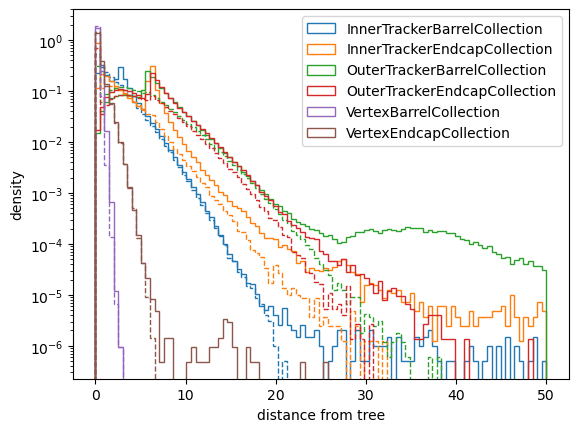

In [8]:



plt.figure()
for i, col in enumerate(collections):
    plt.hist(dists_truth[col], bins = np.linspace(0, 50, 100), histtype = "step", density = True, linestyle = "dashed", color = f"C{i}")
    plt.hist(dists_samples[col], bins = np.linspace(0, 50, 100), histtype = "step", density = True, color = f"C{i}", label = col)
plt.yscale("log")
plt.xlabel("distance from tree")
plt.ylabel("density")
plt.legend()
plt.show()

In [9]:
collections_order = [
    'VertexBarrelCollection',
    'VertexEndcapCollection',
    'InnerTrackerBarrelCollection',
    'InnerTrackerEndcapCollection',
    'OuterTrackerBarrelCollection',
    'OuterTrackerEndcapCollection'
]

# Prepare x positions
width = 0.1  # width of each bar
x_offsets = np.arange(0, len(col_hits_per_layer[collections_order[0]]))  # base positions for first collection

fig, ax = plt.subplots(figsize=(12, 6))

# Keep track of total x positions
x_pos = 0
x_labels = []
x_ticks = []

for coll in collections_order:
    layers = sorted(col_hits_per_layer_samples[coll].keys())  # sort layers numerically
    counts = [col_hits_per_layer_samples[coll][l] for l in layers]

    # compute positions for this collection
    positions = x_pos + np.arange(len(layers))
    ax.bar(positions, counts, width=0.8, label=coll)
    
    # collect labels and ticks
    x_labels.extend([f"{l}" for l in layers])
    x_ticks.extend(positions)
    
    # update x_pos for next collection to avoid overlap
    x_pos = positions[-1] + 1  # add gap between collections

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_ylabel("Number of hits")
ax.set_title("Hits per Detector Layer")
ax.legend()
plt.tight_layout()
plt.yscale("log")
plt.savefig("figures/hits_per_detector_layer.png")
plt.show()

NameError: name 'col_hits_per_layer' is not defined

In [13]:



for col in collections_order:


    

    mask = apply_material_map_hybrid(all_samples_dir, None, col, feature_indices_dict)
    print(np.sum(mask), len(mask))
    print(len(valid_masks[col]))
    loc = np.concatenate([all_samples_dir[col], cell_ids_samples[col].reshape(-1,1)], axis = 1)

    #np.save(f"/pscratch/sd/r/rmastand/muon_collider/npys/flow_samples/{col}.npy", loc)
    print(loc.shape)

2015004 2129166
(2129166, 8)
4090025 4096371
(4096371, 8)
2939504 3926196
(3926196, 8)
1603905 1614679


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 1614679 and the array at index 1 has size 1614678